# Synthetic helicoidal

In [10]:
import velot
import scvelo as scv

# Load data
# adata = velot.datasets.erythroid()
adata = velot.datasets.synthetic_cycle((1000, 2000, 4000, 2000), n_rotations=3, x_amplitude=3, z_drift=20, noise_level=0.3, extra_dimensions=1)

# scv.pp.filter_and_normalize(adata, min_shared_counts=200, min_shared_cells=10)
adata.obsm["X_X"] = adata.X.copy()

# Preprocess
# adata_process = velot.pp.prepare(adata, root_cluster="Blood progenitors 1", cluster_key="celltype")

# velot.pp.normalize(adata)
# velot.pp.select_genes(adata, n_hvg=3000)
velot.pp.scale(adata)
# velot.pp.pca(adata, n_pcs=200)
# velot.pp.neighbors(adata)
# velot.pp.umap(adata)
# velot.pp.pseudotime(adata, root_cluster="Phase_1", cluster_key="celltype")
velot.pp.pseudotime(adata, key="true_pseudotime")
adata.obs["clusters"] = adata.obs["celltype"].cat.codes

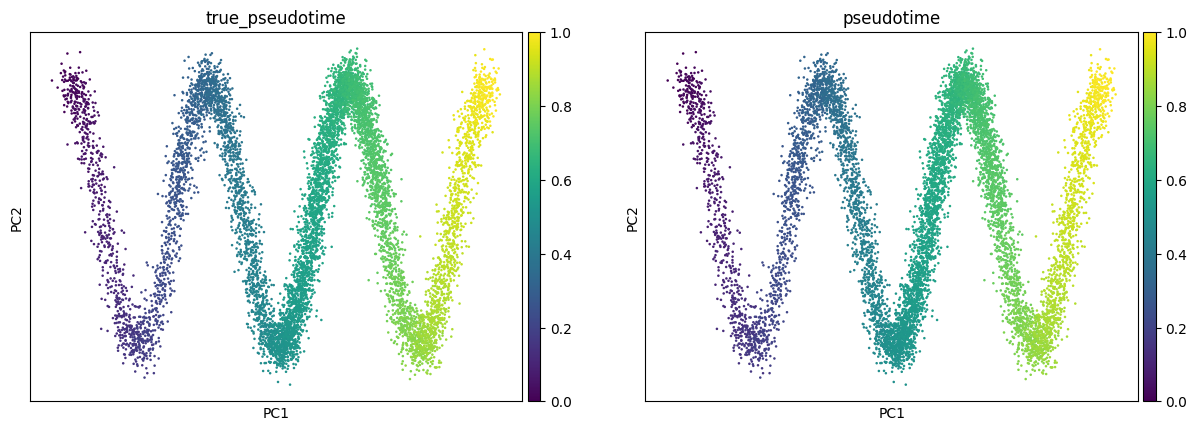

In [11]:
import scanpy as sc
sc.pl.pca(adata, color=["true_pseudotime", "pseudotime"])

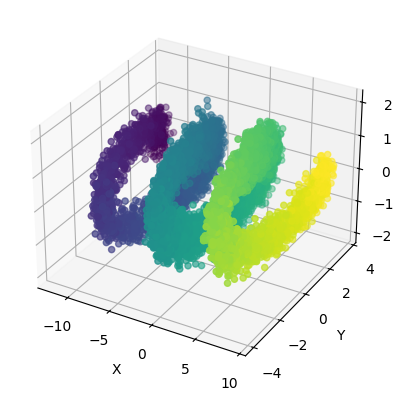

In [12]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # optional in newer versions
import numpy as np

# Example data
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(adata.obsm["X_pca"][:,0], adata.obsm["X_pca"][:,1], adata.obsm["X_pca"][:,2], c=adata.obs["true_pseudotime"])

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

In [13]:
adata_original = adata.copy()

VelOT: Computing velocity field
  Basis: X_pca (3D)
  Cells: 9000
  Smoothing: ON

[1/4] Building spatial-temporal windows...
  Using precomputed spatial labels from 'clusters': 4 clusters
  Built 47 window pairs across 4 clusters (skipped 0 small clusters)
  Window size: 200, step: 180

[2/4] Computing OT velocity...
  OT velocity computed: 8540 cells with velocity, 460 cells without (will be filled by smoothing)

[3/4] Smoothing velocity field...
    epoch 50/200: reg=0.2699 smooth=0.0019
    epoch 100/200: reg=0.2975 smooth=0.0017
    epoch 150/200: reg=0.2234 smooth=0.0019
    epoch 200/200: reg=0.2347 smooth=0.0015
  Smoothing complete: final reg=0.2347, smooth=0.0015

[4/4] Projecting to UMAP...
  Velocity projected to UMAP (9000 cells)

VelOT: Done.


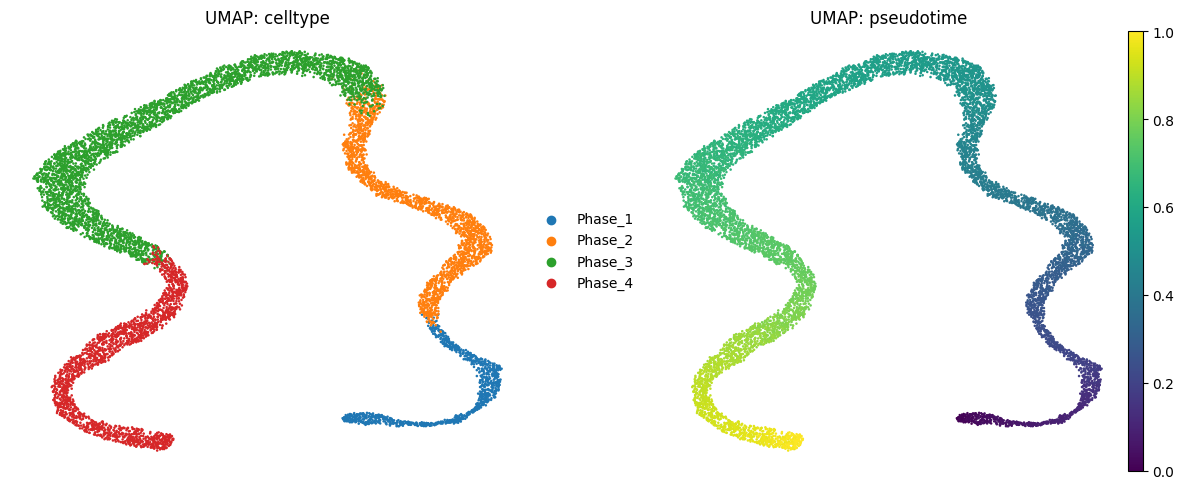

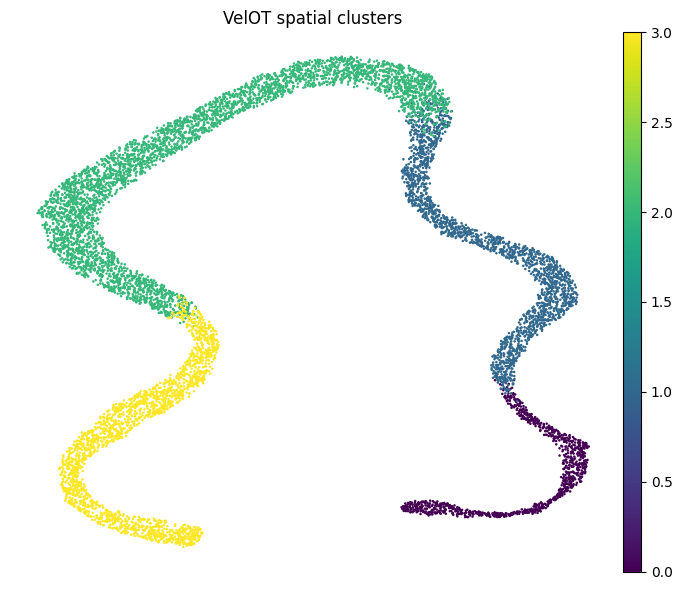

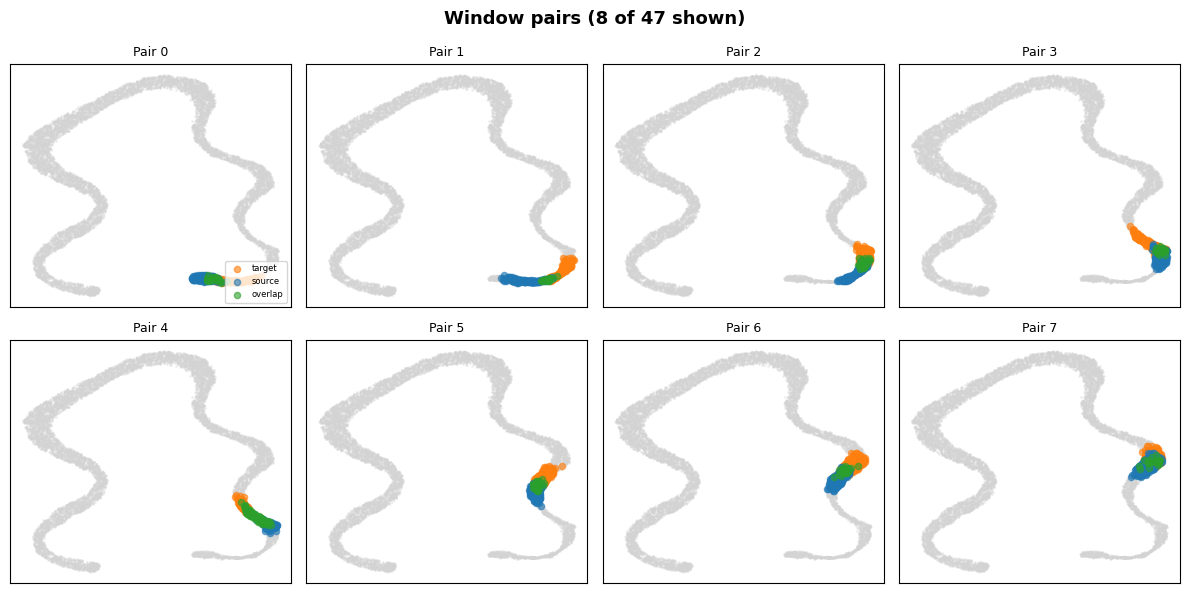

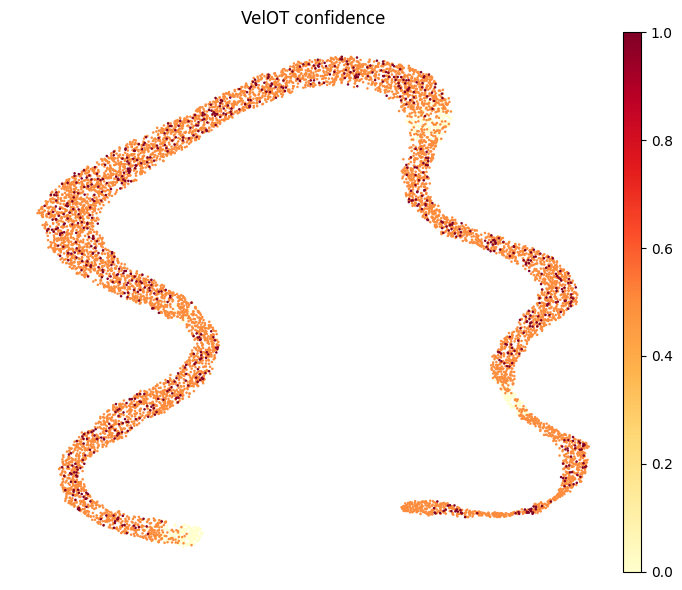

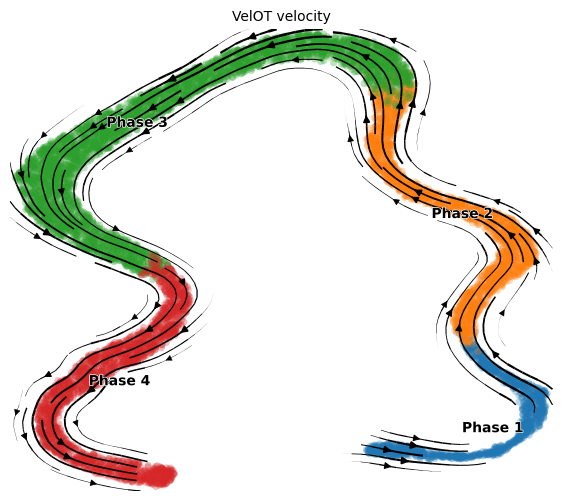

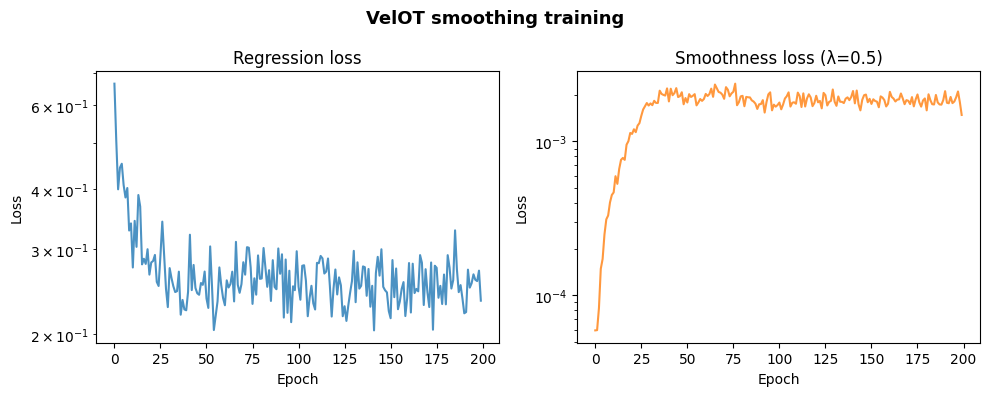

VelOT Velocity Metrics

Inner-Cluster Coherence (mean: 0.944):
                    Phase_1: 0.925
                    Phase_2: 0.960
                    Phase_3: 0.960
                    Phase_4: 0.933

Cross-Boundary Correctness (mean: 0.867):
          Phase_1 → Phase_2        : 0.919
          Phase_2 → Phase_3        : 0.790
          Phase_3 → Phase_4        : 0.892


{'iccoh': {'Phase_1': 0.9248445985913276,
  'Phase_2': 0.9601223506778479,
  'Phase_3': 0.959514923274517,
  'Phase_4': 0.9330077876448631},
 'iccoh_mean': 0.9443724150471389,
 'cbdir': {('Phase_1', 'Phase_2'): 0.9188702307620102,
  ('Phase_2', 'Phase_3'): 0.7901461908425129,
  ('Phase_3', 'Phase_4'): 0.892348904651751},
 'cbdir_mean': 0.867121775418758}

In [14]:
# Compute velocity (full pipeline)
velot.tl.velocity(adata, "X_pca", True, None, 200, 0.1, spatial_key="clusters")

# Visualize
velot.pl.dataset_overview(adata, color="celltype")
velot.pl.spatial_clusters(adata)
velot.pl.windows(adata, max_show=8)
velot.pl.confidence(adata)
velot.pl.velocity_stream(adata, color="celltype")
velot.pl.training_curves(adata)

# Evaluate
# edges = [
#     ("Ductal", "Ngn3 low EP"),
#     ("Ngn3 low EP", "Ngn3 high EP"),
# ]
# edges = [
#     ('Blood progenitors 1', 'Blood progenitors 2'), 
#     ('Blood progenitors 2', 'Erythroid1'),
#     ('Erythroid1', 'Erythroid2'), 
#     ('Erythroid2', 'Erythroid3')
# ]
edges = [
    ('Phase_1', 'Phase_2'),
    ('Phase_2', 'Phase_3'), 
    ('Phase_3', 'Phase_4')
]
velot.metrics.summary(adata, cluster_edges=edges, cluster_key="celltype")

In [16]:
adata_smooth = adata.copy()
adata_smooth

AnnData object with n_obs × n_vars = 9000 × 4
    obs: 'celltype', 'true_pseudotime', 'pseudotime', 'clusters', 'velot_spatial_cluster', 'velot_confidence'
    var: 'mean', 'std'
    uns: 'pca', 'neighbors', 'umap', 'velot_windows', 'velot_smoothing', 'celltype_colors'
    obsm: 'X_spatial_true', 'X_pca', 'X_umap', 'X_X', 'velot_velocity', 'velot_velocity_raw', 'velocity_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [17]:
adata = adata_original.copy()
adata

AnnData object with n_obs × n_vars = 9000 × 4
    obs: 'celltype', 'true_pseudotime', 'pseudotime', 'clusters'
    var: 'mean', 'std'
    uns: 'pca', 'neighbors', 'umap'
    obsm: 'X_spatial_true', 'X_pca', 'X_umap', 'X_X'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

VelOT: Computing velocity field
  Basis: X_pca (3D)
  Cells: 9000
  Smoothing: OFF

[1/4] Building spatial-temporal windows...
  Using precomputed spatial labels from 'clusters': 4 clusters
  Built 47 window pairs across 4 clusters (skipped 0 small clusters)
  Window size: 200, step: 180

[2/4] Computing OT velocity...
  OT velocity computed: 8540 cells with velocity, 460 cells without (will be filled by smoothing)

[3/4] Smoothing: SKIPPED

[4/4] Projecting to UMAP...
  Velocity projected to UMAP (9000 cells)

VelOT: Done.


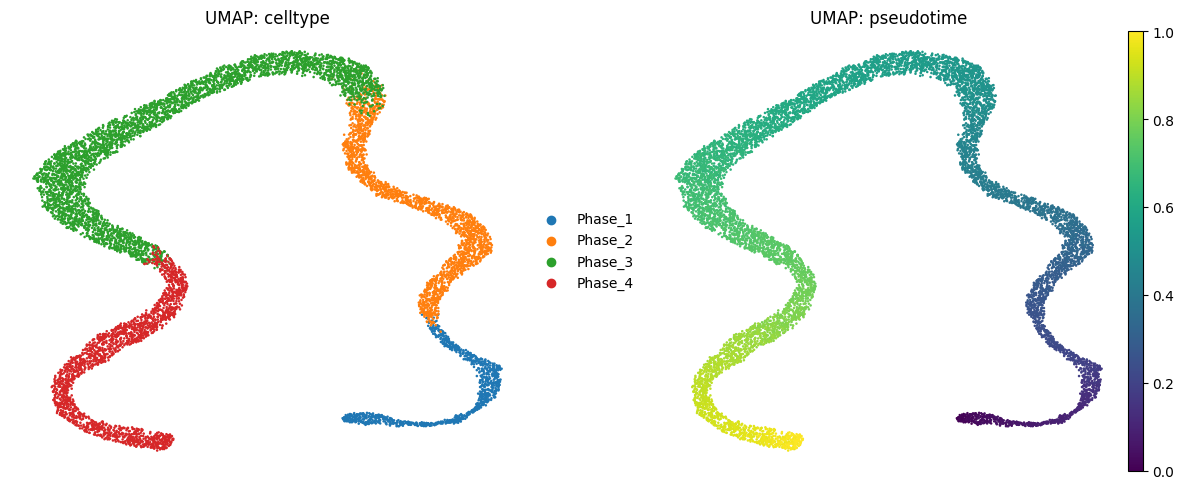

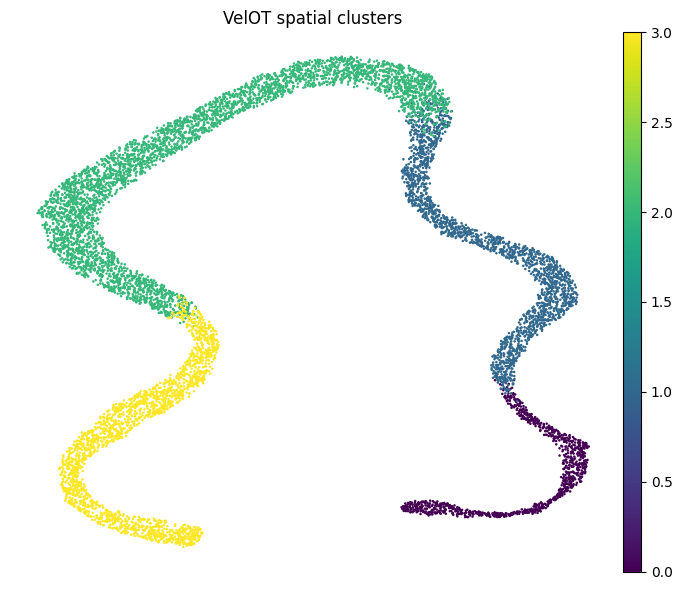

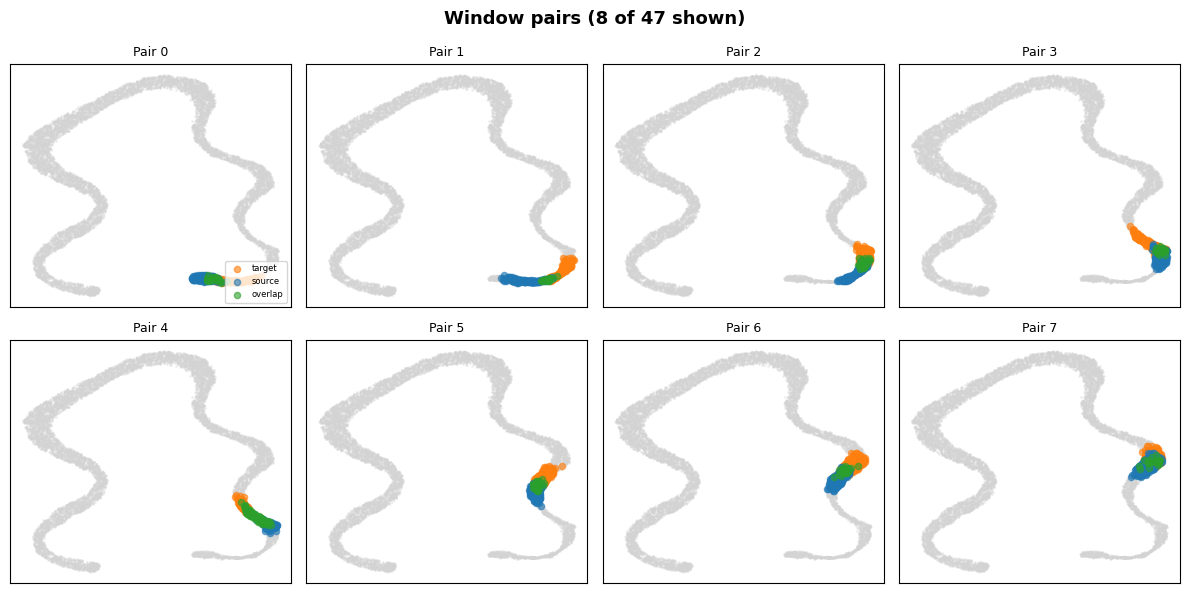

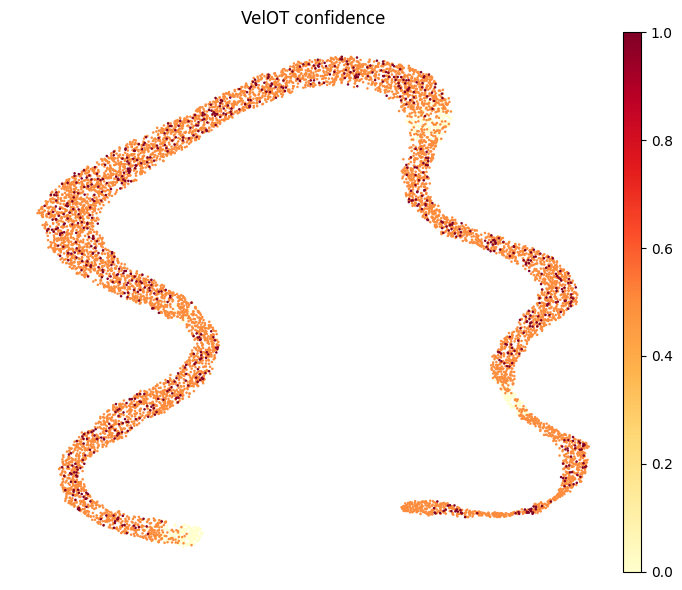

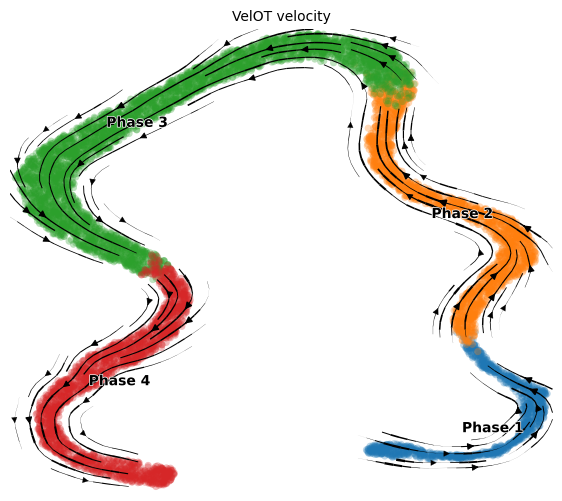

VelOT Velocity Metrics

Inner-Cluster Coherence (mean: 0.645):
                    Phase_1: 0.528
                    Phase_2: 0.629
                    Phase_3: 0.809
                    Phase_4: 0.614

Cross-Boundary Correctness (mean: 0.394):
          Phase_1 → Phase_2        : 0.153
          Phase_2 → Phase_3        : 0.318
          Phase_3 → Phase_4        : 0.711


{'iccoh': {'Phase_1': 0.5278884521946311,
  'Phase_2': 0.6287308709137142,
  'Phase_3': 0.8091234811227769,
  'Phase_4': 0.6135359794571996},
 'iccoh_mean': 0.6448196959220804,
 'cbdir': {('Phase_1', 'Phase_2'): 0.15331196581196582,
  ('Phase_2', 'Phase_3'): 0.31815792951623245,
  ('Phase_3', 'Phase_4'): 0.7114225389421446},
 'cbdir_mean': 0.3942974780901143}

In [20]:
# Compute velocity (full pipeline)
velot.tl.velocity(adata, "X_pca", False, None, 200, 0.1, spatial_key="clusters")

# Visualize
velot.pl.dataset_overview(adata, color="celltype")
velot.pl.spatial_clusters(adata)
velot.pl.windows(adata, max_show=8)
velot.pl.confidence(adata)
velot.pl.velocity_stream(adata, color="celltype")
# velot.pl.training_curves(adata)

# Evaluate
# edges = [
#     ("Ductal", "Ngn3 low EP"),
#     ("Ngn3 low EP", "Ngn3 high EP"),
# ]
# edges = [
#     ('Blood progenitors 1', 'Blood progenitors 2'), 
#     ('Blood progenitors 2', 'Erythroid1'),
#     ('Erythroid1', 'Erythroid2'), 
#     ('Erythroid2', 'Erythroid3')
# ]
edges = [
    ('Phase_1', 'Phase_2'),
    ('Phase_2', 'Phase_3'), 
    ('Phase_3', 'Phase_4')
]
velot.metrics.summary(adata, cluster_edges=edges, cluster_key="celltype")

# Real Pancreas

In [53]:
import velot
import scvelo as scv
import cellrank as cr

# Load data
# adata = velot.datasets.pancreas()
adata = cr.datasets.pancreas("datasets/endocrinogenesis_day15.5.h5ad", kind="preprocessed")

In [54]:
# Preprocess
# scv.pp.filter_and_normalize(adata, min_shared_counts=200, min_shared_cells=10)
# adata.obsm["X_X"] = adata.X.copy()
# adata_process = velot.pp.prepare(adata, root_cluster="Blood progenitors 1", cluster_key="celltype")

# velot.pp.normalize(adata)
# velot.pp.select_genes(adata, n_hvg=3000)
# velot.pp.scale(adata)
velot.pp.pca(adata, n_pcs=200)
# velot.pp.neighbors(adata)
# velot.pp.umap(adata)
velot.pp.pseudotime(adata, root_cluster="Ngn3 low EP", cluster_key="clusters")
adata.obs["clusters_id"] = adata.obs["clusters"].cat.codes

In [55]:
adata_original = adata.copy()

VelOT: Computing velocity field
  Basis: X_umap (2D)
  Cells: 2531
  Smoothing: ON

[1/4] Building spatial-temporal windows...
  Using precomputed spatial labels from 'clusters_id': 7 clusters
  Built 27 window pairs across 7 clusters (skipped 0 small clusters)
  Window size: 100, step: 95

[2/4] Computing OT velocity...
  OT velocity computed: 2351 cells with velocity, 180 cells without (will be filled by smoothing)

[3/4] Smoothing velocity field...
    epoch 50/300: reg=1.5570 smooth=0.0050
    epoch 100/300: reg=1.3812 smooth=0.0086
    epoch 150/300: reg=1.3470 smooth=0.0084
    epoch 200/300: reg=1.3316 smooth=0.0097
    epoch 250/300: reg=1.3524 smooth=0.0102
    epoch 300/300: reg=1.2986 smooth=0.0131
  Smoothing complete: final reg=1.2986, smooth=0.0131

[4/4] UMAP projection: SKIPPED

VelOT: Done.


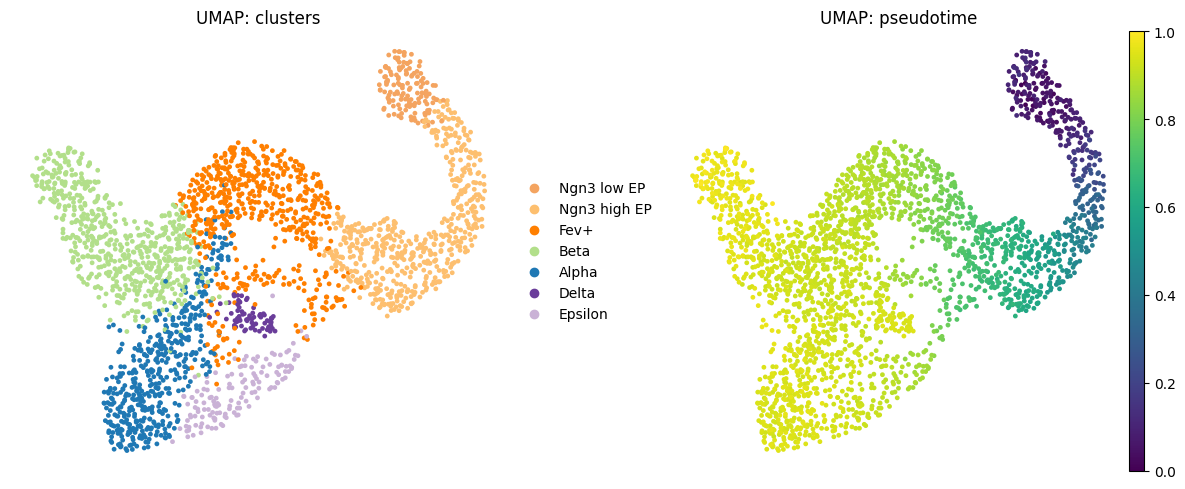

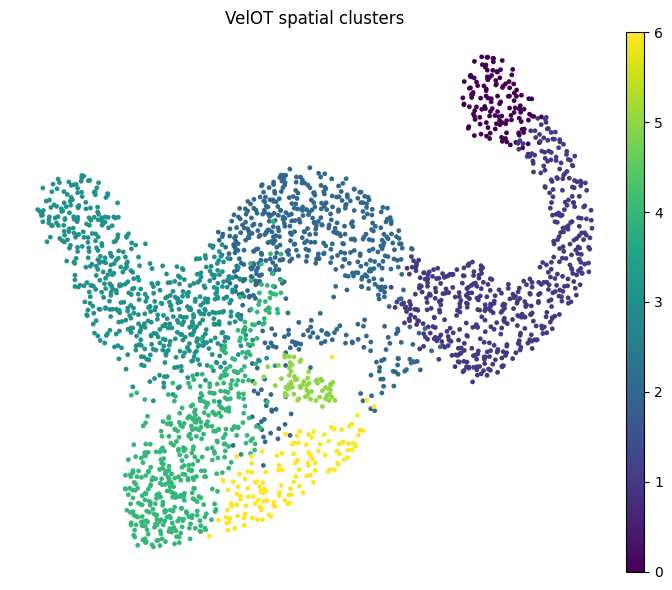

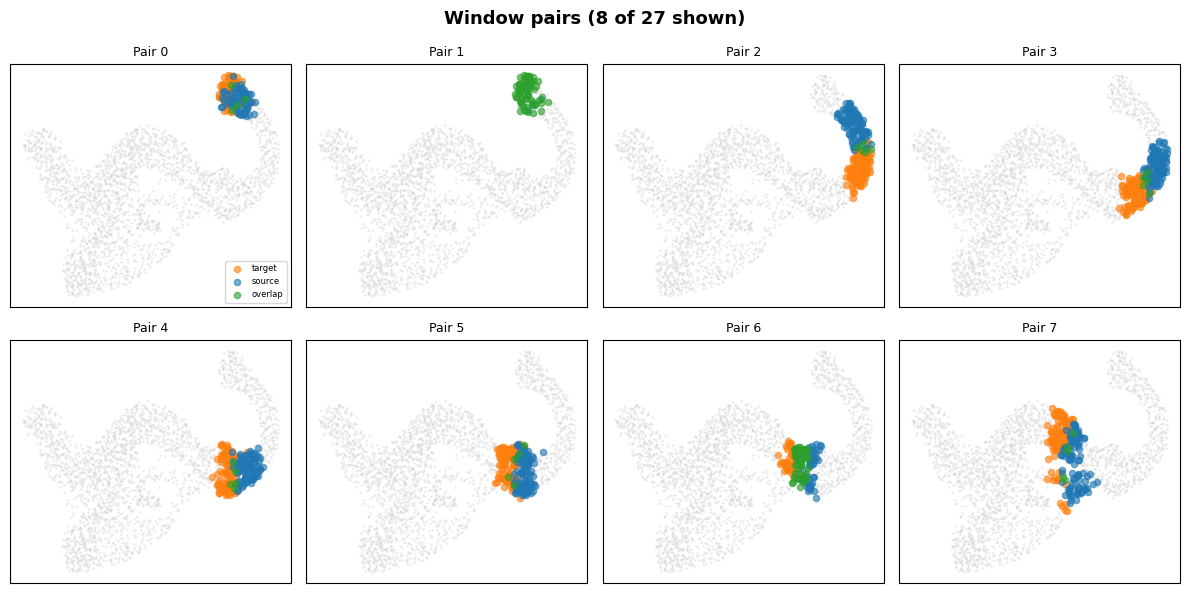

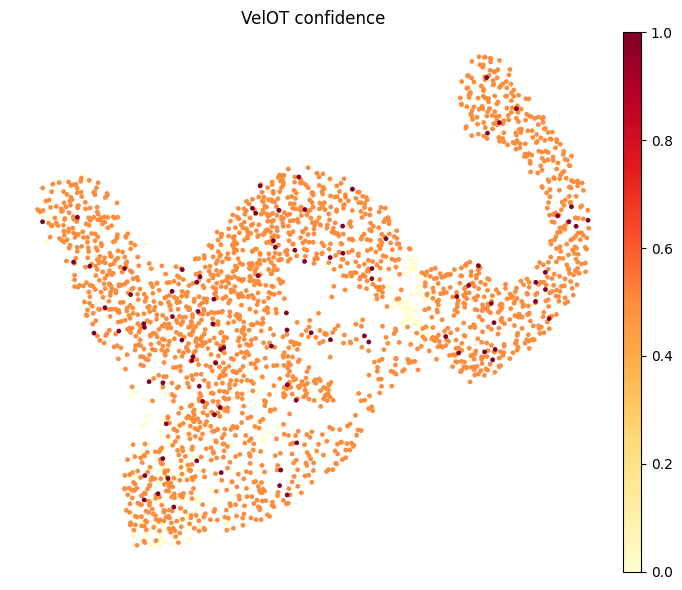

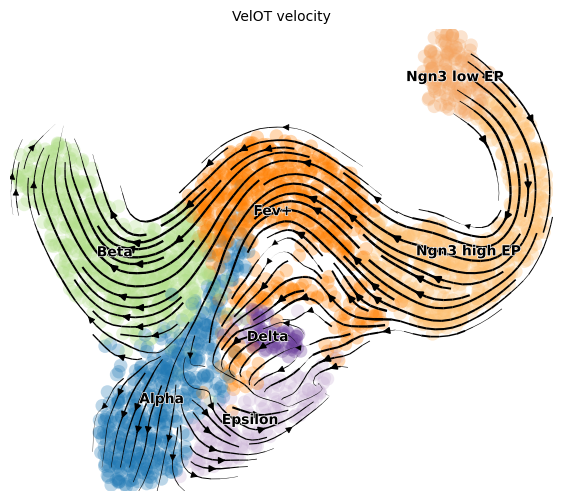

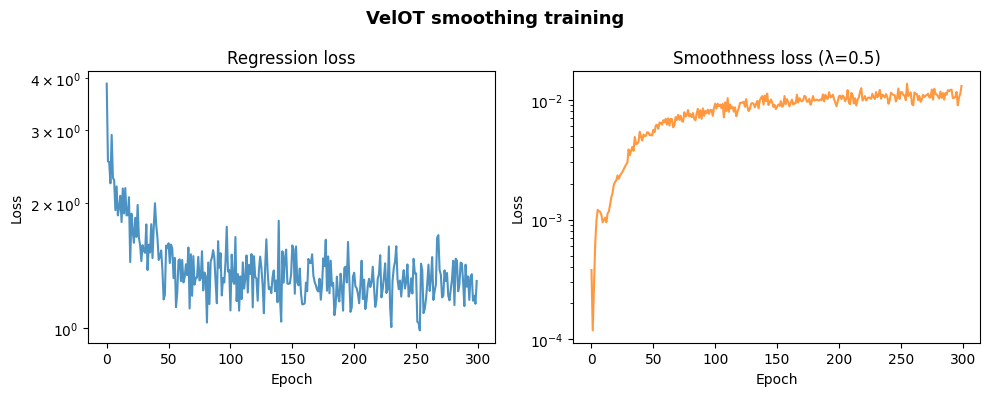

VelOT Velocity Metrics

Inner-Cluster Coherence (mean: 0.787):
                      Alpha: 0.682
                       Beta: 0.911
                      Delta: 0.624
                    Epsilon: 0.638
                       Fev+: 0.935
               Ngn3 high EP: 0.968
                Ngn3 low EP: 0.749

Cross-Boundary Correctness (mean: 0.793):
      Ngn3 low EP → Ngn3 high EP   : 0.977
     Ngn3 high EP → Fev+           : 0.920
             Fev+ → Delta          : 0.513
             Fev+ → Beta           : 0.905
             Fev+ → Epsilon        : 0.686
             Fev+ → Alpha          : 0.758


{'iccoh': {'Alpha': 0.6823526846897662,
  'Beta': 0.910974647954635,
  'Delta': 0.623857028063565,
  'Epsilon': 0.6380352698054838,
  'Fev+': 0.9345262881708315,
  'Ngn3 high EP': 0.9682736348002884,
  'Ngn3 low EP': 0.7485863113926652},
 'iccoh_mean': 0.7866579806967479,
 'cbdir': {('Ngn3 low EP', 'Ngn3 high EP'): 0.9772477522477524,
  ('Ngn3 high EP', 'Fev+'): 0.9195549038245298,
  ('Fev+', 'Delta'): 0.5127976190476191,
  ('Fev+', 'Beta'): 0.9054064915354454,
  ('Fev+', 'Epsilon'): 0.6856305669280911,
  ('Fev+', 'Alpha'): 0.7584307986789225},
 'cbdir_mean': 0.7931780220437267}

In [57]:
# Compute velocity (full pipeline)
velot.tl.velocity(adata, "X_umap", True, None, 100, 0.05, spatial_key="clusters_id", reg=0.1, n_epochs=300, project_umap=False)

# Visualize
velot.pl.dataset_overview(adata, color="clusters")
velot.pl.spatial_clusters(adata)
velot.pl.windows(adata, max_show=8)
velot.pl.confidence(adata)
velot.pl.velocity_stream(adata, color="clusters")
velot.pl.training_curves(adata)

# Evaluate
edges = [
    ('Ngn3 low EP', 'Ngn3 high EP'), 
    ('Ngn3 high EP', 'Fev+'),
    ('Fev+', 'Delta'), 
    ('Fev+', 'Beta'),
    ('Fev+','Epsilon'),
    ('Fev+','Alpha')
]

velot.metrics.summary(adata, cluster_edges=edges, cluster_key="clusters")

# Real Erythroid

In [58]:
import velot
import scvelo as scv
import cellrank as cr

# Load data
adata = velot.datasets.dentategyrus()

100%|██████████| 23.7M/23.7M [00:00<00:00, 59.9MB/s]


In [61]:
# Preprocess
scv.pp.filter_and_normalize(adata, min_shared_counts=200, min_shared_cells=10)
# adata.obsm["X_X"] = adata.X.copy()
# adata_process = velot.pp.prepare(adata, root_cluster="Blood progenitors 1", cluster_key="celltype")

# velot.pp.normalize(adata)
# velot.pp.select_genes(adata, n_hvg=3000)
# velot.pp.scale(adata)
velot.pp.pca(adata, n_pcs=200)
velot.pp.neighbors(adata)
# velot.pp.umap(adata)
velot.pp.pseudotime(adata, root_cluster="Neuroblast", cluster_key="clusters")
adata.obs["clusters_id"] = adata.obs["clusters"].cat.codes

In [62]:
adata_original = adata.copy()

VelOT: Computing velocity field
  Basis: X_pca (200D)
  Cells: 2930
  Smoothing: ON

[1/4] Building spatial-temporal windows...
  Using precomputed spatial labels from 'clusters_id': 14 clusters
  Built 39 window pairs across 11 clusters (skipped 3 small clusters)
  Window size: 100, step: 95

[2/4] Computing OT velocity...
  OT velocity computed: 2754 cells with velocity, 176 cells without (will be filled by smoothing)

[3/4] Smoothing velocity field...


/home/user/miniforge3/envs/velot/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:666: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/home/user/miniforge3/envs/velot/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:666: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


    epoch 50/300: reg=890.6790 smooth=0.2019
    epoch 100/300: reg=752.5905 smooth=0.7639
    epoch 150/300: reg=711.5177 smooth=1.0668
    epoch 200/300: reg=673.1306 smooth=1.2172
    epoch 250/300: reg=698.9916 smooth=1.3936
    epoch 300/300: reg=635.6046 smooth=1.2939
  Smoothing complete: final reg=635.6046, smooth=1.2939

[4/4] Projecting to UMAP...
  Velocity projected to UMAP (2930 cells)

VelOT: Done.


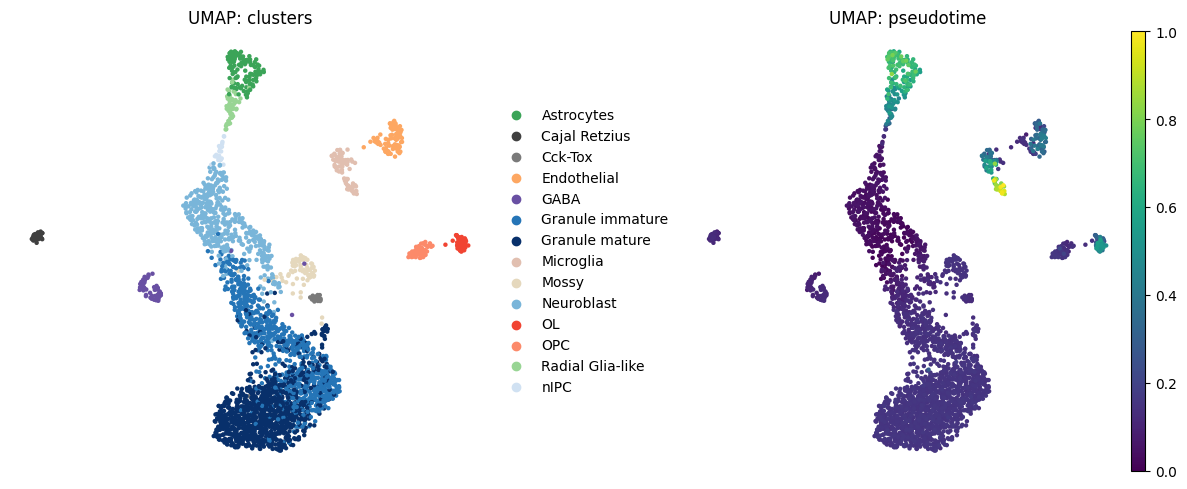

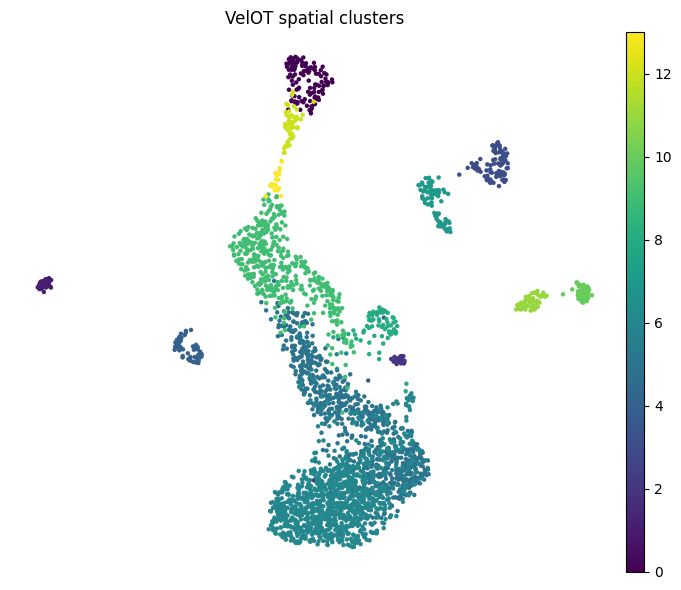

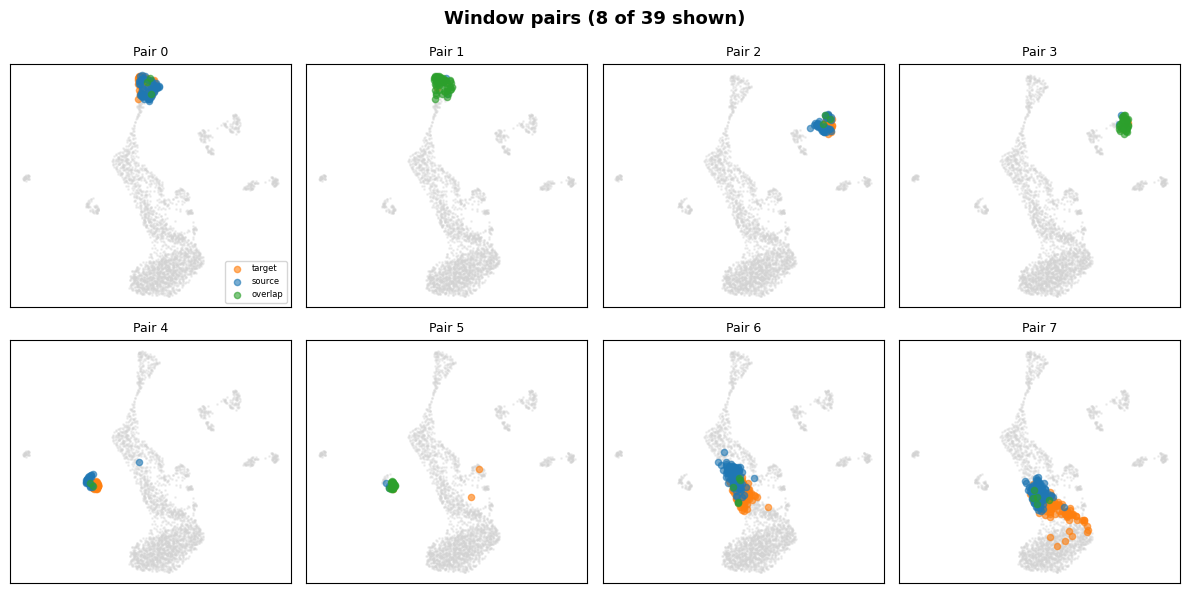

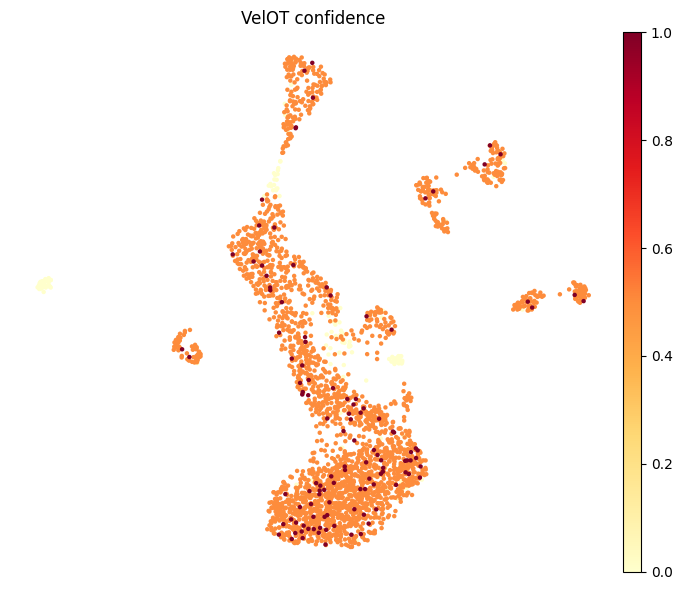

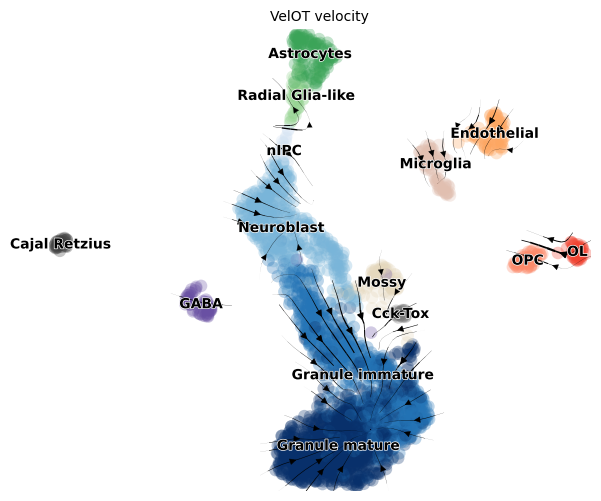

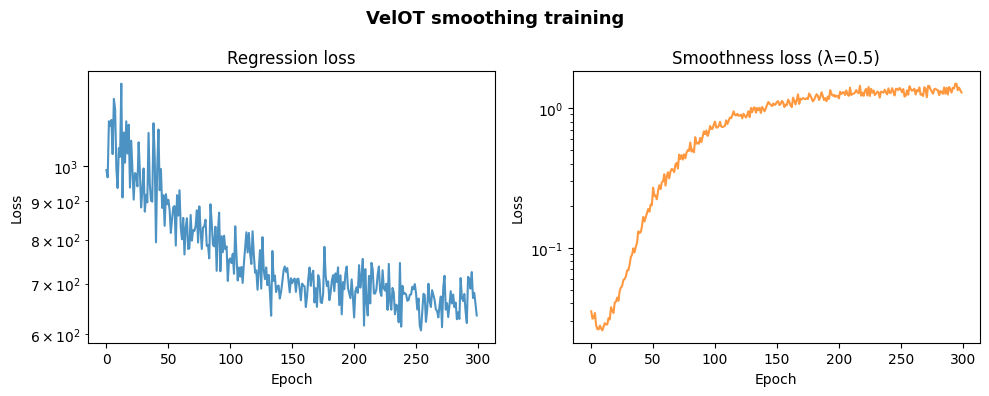

VelOT Velocity Metrics

Inner-Cluster Coherence (mean: 0.448):
                 Astrocytes: 0.254
              Cajal Retzius: 0.796
                    Cck-Tox: 0.640
                Endothelial: 0.281
                       GABA: 0.755
           Granule immature: 0.483
             Granule mature: 0.231
                  Microglia: 0.304
                      Mossy: 0.390
                 Neuroblast: 0.523
                         OL: 0.546
                        OPC: 0.109
           Radial Glia-like: 0.270
                       nIPC: 0.694

Cross-Boundary Correctness (mean: 0.567):
              OPC → OL             : 0.391
  Radial Glia-like → Astrocytes     : 0.754
       Neuroblast → Granule immature: 0.558


{'iccoh': {'Astrocytes': 0.25369262801376385,
  'Cajal Retzius': 0.7958242353830602,
  'Cck-Tox': 0.6401034711122756,
  'Endothelial': 0.28121025454536513,
  'GABA': 0.7550618410102456,
  'Granule immature': 0.4829056111087667,
  'Granule mature': 0.2309605058910981,
  'Microglia': 0.30445682719697076,
  'Mossy': 0.38980244037619544,
  'Neuroblast': 0.5229859135365706,
  'OL': 0.5460362752065175,
  'OPC': 0.10887522147801444,
  'Radial Glia-like': 0.270089471365347,
  'nIPC': 0.6939362487789194},
 'iccoh_mean': 0.44828149607165074,
 'cbdir': {('OPC', 'OL'): 0.390625,
  ('Radial Glia-like', 'Astrocytes'): 0.75380876433508,
  ('Neuroblast', 'Granule immature'): 0.5576202240064062},
 'cbdir_mean': 0.567351329447162}

In [63]:
# Compute velocity (full pipeline)
velot.tl.velocity(adata, "X_pca", True, None, 100, 0.05, spatial_key="clusters_id", reg=0.1, n_epochs=300, project_umap=True)

# Visualize
velot.pl.dataset_overview(adata, color="clusters")
velot.pl.spatial_clusters(adata)
velot.pl.windows(adata, max_show=8)
velot.pl.confidence(adata)
velot.pl.velocity_stream(adata, color="clusters")
velot.pl.training_curves(adata)

# Evaluate
edges = [
    ('OPC', 'OL'),
    ('Radial Glia-like', 'Astrocytes'),
    ('Neuroblast', 'Granule immature')
]

velot.metrics.summary(adata, cluster_edges=edges, cluster_key="clusters")